In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import spacy

In [2]:
df = pd.read_csv("Real Estate Data V21.csv")

In [3]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:")
print(df.info())

Dataset Shape: (14528, 9)

Column Names:
 ['Name', 'Property Title', 'Price', 'Location', 'Total_Area', 'Price_per_SQFT', 'Description', 'Baths', 'Balcony']

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14528 entries, 0 to 14527
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Name            14528 non-null  object 
 1   Property Title  14528 non-null  object 
 2   Price           14528 non-null  object 
 3   Location        14528 non-null  object 
 4   Total_Area      14528 non-null  int64  
 5   Price_per_SQFT  14528 non-null  float64
 6   Description     14528 non-null  object 
 7   Baths           14528 non-null  int64  
 8   Balcony         14528 non-null  object 
dtypes: float64(1), int64(2), object(6)
memory usage: 1021.6+ KB
None


In [4]:
print("First 5 Rows:\n")
print(df.head())


First 5 Rows:

                                      Name  \
0                         Casagrand ECR 14   
1    Ramanathan Nagar, Pozhichalur,Chennai   
2                              DAC Prapthi   
3  Naveenilaya,Chepauk, Triplicane,Chennai   
4                 VGN Spring Field Phase 1   

                                      Property Title     Price  \
0  4 BHK Flat for sale in Kanathur Reddikuppam, C...  ₹1.99 Cr   
1  10 BHK Independent House for sale in Pozhichal...  ₹2.25 Cr   
2      3 BHK Flat for sale in West Tambaram, Chennai   ₹1.0 Cr   
3  7 BHK Independent House for sale in Triplicane...  ₹3.33 Cr   
4              2 BHK Flat for sale in Avadi, Chennai   ₹48.0 L   

                                   Location  Total_Area  Price_per_SQFT  \
0             Kanathur Reddikuppam, Chennai        2583          7700.0   
1     Ramanathan Nagar, Pozhichalur,Chennai        7000          3210.0   
2  Kasthuribai Nagar, West Tambaram,Chennai        1320          7580.0   
3   Naveeni

In [5]:
print("Missing Values:\n")
print(df.isnull().sum())

Missing Values:

Name              0
Property Title    0
Price             0
Location          0
Total_Area        0
Price_per_SQFT    0
Description       0
Baths             0
Balcony           0
dtype: int64


In [6]:
print("Numerical Summary:\n")
print(df.describe())

Numerical Summary:

         Total_Area  Price_per_SQFT         Baths
count  14528.000000    14528.000000  14528.000000
mean    1297.916988    11719.456222      2.751239
std     1245.694305    49036.068632      0.898243
min       70.000000        0.000000      1.000000
25%      650.000000     4480.000000      2.000000
50%     1000.000000     6050.000000      3.000000
75%     1439.000000     9312.500000      3.000000
max    35000.000000   999000.000000      6.000000


In [7]:
print("Unique values per column:\n")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique values")


Unique values per column:

Name: 9998 unique values
Property Title: 6507 unique values
Price: 891 unique values
Location: 7050 unique values
Total_Area: 1774 unique values
Price_per_SQFT: 2094 unique values
Description: 14490 unique values
Baths: 6 unique values
Balcony: 2 unique values


In [8]:
print("Top 10 Property Titles:\n")
print(df['Property Title'].value_counts().head(10))

Top 10 Property Titles:

Property Title
2 BHK Flat for sale in Electronic City, Bangalore    53
2 BHK Flat for sale in Hadapsar, Pune                39
1 BHK Flat for sale in Mira Road East, Mumbai        38
2 BHK Flat for sale in Mira Road East, Mumbai        33
2 BHK Flat for sale in Wagholi, Pune                 31
2 BHK Flat for sale in Pimpri, Pune                  29
2 BHK Flat for sale in Rajarhat, Kolkata             29
2 BHK Flat for sale in JP Nagar, Bangalore           28
2 BHK Flat for sale in Whitefield, Bangalore         28
2 BHK Flat for sale in Bommasandra, Bangalore        27
Name: count, dtype: int64


In [9]:
print("Top 10 Locations:\n")
print(df['Location'].value_counts().head(10))


Top 10 Locations:

Location
Sector 12 Dwarka, New Delhi                        44
Wagholi, Pune                                      39
Bannerughatta, Bangalore                           35
Horamavu Agara, Horamavu,Bangalore                 32
Chakan, Pune                                       32
Mattanahalli, Bangalore                            31
Veer Sandra, Electronic City,Bangalore             31
Yelahanka, Bangalore                               30
Veer Sandra, Electronic City Phase II,Bangalore    29
Hindustan Antibiotics Colony, Pimpri,Pune          27
Name: count, dtype: int64


In [10]:
print("Sample Descriptions:\n")
print(df['Description'].sample(5).tolist())


Sample Descriptions:

["2 row houses combined from inside. 8 bedrooms converted to 5 , Living room of 600 sq ft. 4 bathrooms, 1 puja room, double terrace , 4 to 6 car parkings in stilt. offices and rooms in stilt area, facing lush garden at the backside of house. Low maintenance and best location. Next to freeway to town. More About This Property Looking for a 5 BHK Independent House for sale in Mumbai? Your search ends here. Buy this 5 BHK property in Mumbai's finest location, Anushakti Nagar. This is an owner listed property and there is no brokerage involved. This Independent House is available at a reasonable pri...", "One of the finest property in Kumaraswamy Layout is now available for sale. This is a 10 BHK Independent House posted directly by owner. Make it yours now. The price of this Independent House is Rs 2.5 Cr. Other charges when you move into this property include maintenance, which is Rs 0. This Independent House is spacious with a built-up area of 5000 Square feet. The

In [11]:
def convert_price(price_str):
    if pd.isna(price_str):
        return None
    price_str = str(price_str).replace("₹", "").replace(",", "").strip().lower()
    try:
        if "cr" in price_str:
            return float(re.findall(r"[\d\.]+", price_str)[0]) * 1e7
        elif "l" in price_str:
            return float(re.findall(r"[\d\.]+", price_str)[0]) * 1e5
        else:
            return float(re.findall(r"[\d\.]+", price_str)[0])
    except:
        return None

df['Price_Num'] = df['Price'].apply(convert_price)


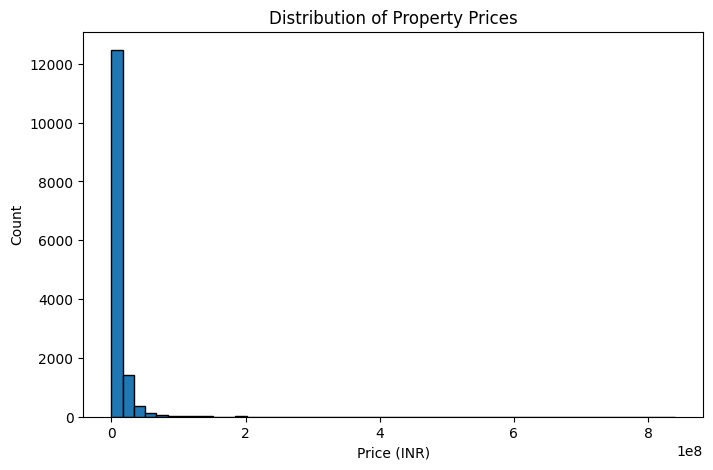

In [12]:
# Histogram of Prices
plt.figure(figsize=(8,5))
df['Price_Num'].dropna().plot(kind='hist', bins=50, edgecolor='black')
plt.title("Distribution of Property Prices")
plt.xlabel("Price (INR)")
plt.ylabel("Count")
plt.show()


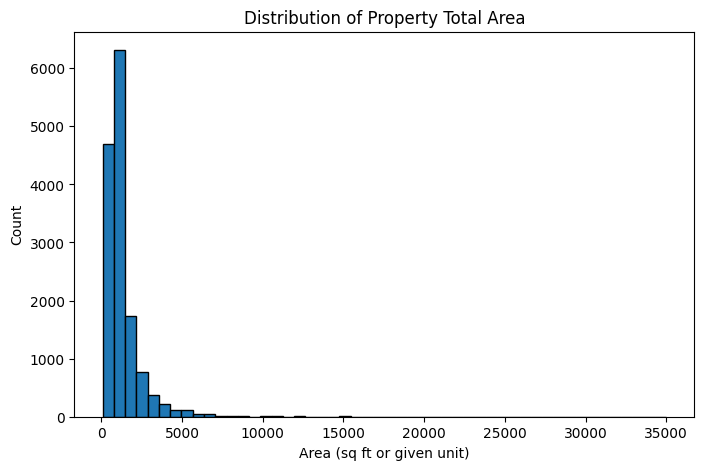

In [13]:
#Histogram of Total Area
plt.figure(figsize=(8,5))
df['Total_Area'].plot(kind='hist', bins=50, edgecolor='black')
plt.title("Distribution of Property Total Area")
plt.xlabel("Area (sq ft or given unit)")
plt.ylabel("Count")
plt.show()

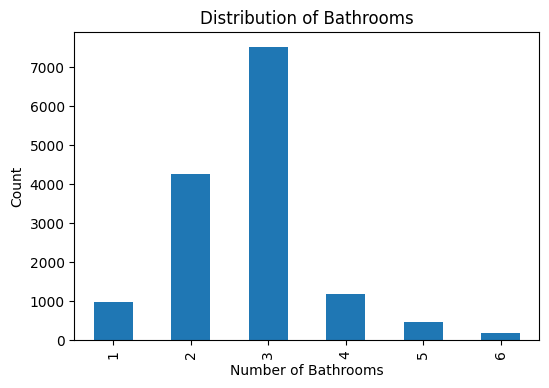

In [14]:
#Bathrooms distribution
plt.figure(figsize=(6,4))
df['Baths'].value_counts().sort_index().plot(kind='bar')
plt.title("Distribution of Bathrooms")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Count")
plt.show()


In [15]:
nlp = spacy.load("en_core_web_sm")

In [22]:
def extract_bedrooms_nlp(text):
    text = str(text).lower()
    doc = nlp(text)

    # Dictionary for word → number
    word_to_num = {
        "one": 1, "two": 2, "three": 3, "four": 4, "five": 5,
        "six": 6, "seven": 7, "eight": 8, "nine": 9, "ten": 10,
        "eleven": 11, "twelve": 12
    }

    for token in doc:
        if token.like_num:  
            try:
                num = int(token.text) #"3" "2"
            except ValueError:
                num = word_to_num.get(token.text.lower())  # "Three" , "Two"

            if num is None:
                continue

            # Check nearby tokens for bedroom keywords
            next_tokens = [t.text for t in doc[token.i:token.i+3]]
            if any(w in next_tokens for w in ["bhk", "bedroom", "bedrooms", "room", "rooms"]):
                return num
    return None


In [23]:
df["Num_Bedrooms"] = df["Property Title"].apply(extract_bedrooms_nlp)
print(df[["Property Title", "Num_Bedrooms"]].head(20))


                                       Property Title  Num_Bedrooms
0   4 BHK Flat for sale in Kanathur Reddikuppam, C...           4.0
1   10 BHK Independent House for sale in Pozhichal...          10.0
2       3 BHK Flat for sale in West Tambaram, Chennai           3.0
3   7 BHK Independent House for sale in Triplicane...           7.0
4               2 BHK Flat for sale in Avadi, Chennai           2.0
5            2 BHK Flat for sale in Siruseri, Chennai           2.0
6           2 BHK Flat for sale in Sembakkam, Chennai           2.0
7   3 BHK Independent House for sale in Mahindra W...           3.0
8       2 BHK Flat for sale in West Tambaram, Chennai           2.0
9           1 BHK Flat for sale in Chromepet, Chennai           1.0
10  1 BHK Flat for sale in Mahindra World City, Ch...           1.0
11       3 BHK Flat for sale in Pallikaranai, Chennai           3.0
12     6 BHK Villa for sale in West Mambalam, Chennai           6.0
13        2 BHK Flat for sale in Ashok Nagar, Ch